# 09. ETF Ex-dividend Strategy Backtest

本 Notebook 是一份**獨立策略回測 Notebook**。

它不依賴前一份研究 Notebook 輸出的 CSV，而是從以下兩個 processed data 重新開始：

- `data/processed/etf_daily_panel.csv`
- `data/processed/etf_dividend_events.csv`

流程：

1. 讀取資料
2. 清洗 ETF symbol
3. 建立 ETF universe
4. 建立除息事件視窗資料
5. 建立 D-10 → D-1 除息前卡位策略
6. 比較多種 universe：
   - Naive All ETF
   - Filtered All ETF
   - Market Cap Core
   - High Dividend Core
7. 產出策略交易表、basket return、資金曲線、回撤、分 ETF 與分年度績效

> Strategy v1 目標：先確認「除息前 alpha」能否轉成策略級資金曲線。  
> 這不是最終正式回測，尚未處理公告日可交易性、實際資金占用、滑價與每日 portfolio simulation。


## 0. Import packages and set paths

In [1]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

PANEL_PATH = PROJECT_ROOT / "data" / "processed" / "etf_daily_panel.csv"
EVENTS_PATH = PROJECT_ROOT / "data" / "processed" / "etf_dividend_events.csv"

OUTPUT_DIR = PROJECT_ROOT / "data" / "strategy"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("PANEL_PATH exists:", PANEL_PATH.exists(), PANEL_PATH)
print("EVENTS_PATH exists:", EVENTS_PATH.exists(), EVENTS_PATH)
print("OUTPUT_DIR:", OUTPUT_DIR)


C:\Users\USER\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\USER\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


PROJECT_ROOT: C:\Users\USER\Desktop\ETF-alpha-lab
PANEL_PATH exists: True C:\Users\USER\Desktop\ETF-alpha-lab\data\processed\etf_daily_panel.csv
EVENTS_PATH exists: True C:\Users\USER\Desktop\ETF-alpha-lab\data\processed\etf_dividend_events.csv
OUTPUT_DIR: C:\Users\USER\Desktop\ETF-alpha-lab\data\strategy


## 1. ETF symbol cleaning

台灣 ETF 代碼有 4 碼、5 碼、6 碼，不能一律 `.zfill(4)`。

例如：

- `0050`
- `0056`
- `00713`
- `00878`
- `00919`
- `006208`

如果 CSV 或 Excel 把前導零吃掉，必須用 mapping 修正。


In [2]:
def fix_tw_etf_symbol(x):
    """
    Normalize Taiwan ETF symbols while preserving leading zeros.

    Examples:
    - 50 -> 0050
    - 713 / 0713 -> 00713
    - 6208 -> 006208
    """

    if pd.isna(x):
        return np.nan

    s = str(x).strip()

    if s.endswith(".0"):
        s = s[:-2]

    symbol_fix_map = {
        "50": "0050",
        "0050": "0050",
        "52": "0052",
        "0052": "0052",
        "56": "0056",
        "0056": "0056",
        "713": "00713",
        "0713": "00713",
        "00713": "00713",
        "878": "00878",
        "0878": "00878",
        "00878": "00878",
        "919": "00919",
        "0919": "00919",
        "00919": "00919",
        "929": "00929",
        "0929": "00929",
        "00929": "00929",
        "939": "00939",
        "0939": "00939",
        "00939": "00939",
        "940": "00940",
        "0940": "00940",
        "00940": "00940",
        "6208": "006208",
        "006208": "006208",
    }

    if s in symbol_fix_map:
        return symbol_fix_map[s]

    if len(s) <= 4:
        return s.zfill(4)

    return s


# Quick sanity check
test_symbols = ["50", "0050", "713", "0713", "00713", "878", "6208", "006208"]
pd.DataFrame({
    "raw": test_symbols,
    "fixed": [fix_tw_etf_symbol(x) for x in test_symbols]
})


,raw,fixed
0,50,0050
1,0050,0050
2,713,00713
3,0713,00713
4,00713,00713
5,878,00878
6,6208,006208
7,006208,006208


## 2. Data loading functions

In [3]:
def load_etf_panel(panel_path):
    """Load ETF daily panel data."""

    panel = pd.read_csv(panel_path, dtype={"symbol": str})
    panel["symbol"] = panel["symbol"].apply(fix_tw_etf_symbol)

    if "date" in panel.columns:
        panel["date"] = pd.to_datetime(panel["date"], errors="coerce")

    panel = (
        panel
        .dropna(subset=["symbol", "date"])
        .sort_values(["symbol", "date"])
        .reset_index(drop=True)
    )

    return panel


def load_etf_dividend_events(events_path):
    """Load ETF dividend events data."""

    events = pd.read_csv(events_path, dtype={"symbol": str})
    events["symbol"] = events["symbol"].apply(fix_tw_etf_symbol)

    for col in ["ex_date", "record_date", "pay_date", "announcement_date"]:
        if col in events.columns:
            events[col] = pd.to_datetime(events[col], errors="coerce")

    events = (
        events
        .dropna(subset=["symbol", "ex_date"])
        .sort_values(["symbol", "ex_date"])
        .reset_index(drop=True)
    )

    return events


def build_valid_etf_universe(
    panel_all,
    event_summary,
    exclude_keywords=None,
):
    """Build valid ETF universe from panel and dividend event data."""

    if exclude_keywords is None:
        exclude_keywords = [
            "正2", "反1", "反向", "槓桿", "期貨", "VIX", "期信",
            "2X", "Bear", "Bull", "Inverse", "Leveraged",
        ]

    name_col = None

    for candidate in ["etf_name", "fund_name", "name"]:
        if candidate in panel_all.columns:
            name_col = candidate
            break

    if name_col is None:
        for candidate in ["etf_name", "fund_name", "name"]:
            if candidate in event_summary.columns:
                name_col = candidate
                break

    if name_col and name_col in panel_all.columns:
        etf_info = panel_all[["symbol", name_col]].drop_duplicates("symbol").copy()
    elif name_col and name_col in event_summary.columns:
        etf_info = event_summary[["symbol", name_col]].drop_duplicates("symbol").copy()
    else:
        etf_info = panel_all[["symbol"]].drop_duplicates().copy()
        etf_info["etf_name"] = ""
        name_col = "etf_name"

    etf_info["name_for_filter"] = etf_info[name_col].astype(str)
    etf_info["is_excluded_by_name"] = etf_info["name_for_filter"].apply(
        lambda x: any(k in x for k in exclude_keywords)
    )

    valid_symbols = sorted(
        set(etf_info.loc[~etf_info["is_excluded_by_name"], "symbol"])
        & set(event_summary["symbol"])
        & set(panel_all["symbol"])
    )

    return valid_symbols, etf_info


## 3. Load and inspect data

In [4]:
panel_all = load_etf_panel(PANEL_PATH)
event_summary = load_etf_dividend_events(EVENTS_PATH)

valid_symbols, etf_info = build_valid_etf_universe(
    panel_all=panel_all,
    event_summary=event_summary,
)

print("panel_all shape:", panel_all.shape)
print("panel date range:", panel_all["date"].min(), "to", panel_all["date"].max())
print("panel symbol count:", panel_all["symbol"].nunique())
print("panel symbols:", sorted(panel_all["symbol"].unique()))

print("\nevent_summary shape:", event_summary.shape)
print("event date range:", event_summary["ex_date"].min(), "to", event_summary["ex_date"].max())
print("event symbol count:", event_summary["symbol"].nunique())
print("event symbols:", sorted(event_summary["symbol"].unique()))

print("\nvalid symbol count:", len(valid_symbols))
print("valid symbols:", valid_symbols)

print("\nOnly in panel:")
print(sorted(set(panel_all["symbol"]) - set(event_summary["symbol"])))

print("\nOnly in events:")
print(sorted(set(event_summary["symbol"]) - set(panel_all["symbol"])))

display(etf_info)
display(panel_all.head())
display(event_summary.head())


panel_all shape: (16224, 19)
panel date range: 2016-01-04 00:00:00 to 2026-05-18 00:00:00
panel symbol count: 10
panel symbols: ['0050', '0052', '0056', '006208', '00713', '00878', '00919', '00929', '00939', '00940']

event_summary shape: (208, 9)
event date range: 2016-05-04 00:00:00 to 2026-06-18 00:00:00
event symbol count: 10
event symbols: ['0050', '0052', '0056', '006208', '00713', '00878', '00919', '00929', '00939', '00940']

valid symbol count: 10
valid symbols: ['0050', '0052', '0056', '006208', '00713', '00878', '00919', '00929', '00939', '00940']

Only in panel:
[]

Only in events:
[]


,symbol,etf_name,name_for_filter,is_excluded_by_name
0,0050,元大台灣50,元大台灣50,False
20,0052,富邦科技,富邦科技,False
31,0056,元大高股息,元大高股息,False
50,006208,富邦台50,富邦台50,False
69,00713,元大台灣高息低波,元大台灣高息低波,False
89,00878,國泰永續高股息,國泰永續高股息,False
112,00919,群益台灣精選高息,群益台灣精選高息,False
125,00929,復華台灣科技優息,復華台灣科技優息,False
161,00939,統一台灣高息動能,統一台灣高息動能,False
184,00940,元大台灣價值高息,元大台灣價值高息,False


,date,symbol,open,high,low,close,adj_close,volume,nav,prev_nav,nav_change,nav_change_pct,market_price,premium_discount,close_to_nav,market_price_to_nav,close_ret,nav_ret,price_nav_ret_spread
0,2016-01-04,0050,15.2000,15.2375,14.7625,14.8875,10.816450,67712252,59.34,61.22,-1.88,-0.0307,59.55,0.0035,-0.749115,0.003539,NaN,NaN,NaN
1,2016-01-05,0050,14.8750,14.9375,14.7125,14.7625,10.725632,87135876,59.01,59.34,-0.33,-0.0056,59.05,0.0007,-0.749831,0.000678,-0.008396,-0.005561,-0.002835
2,2016-01-06,0050,14.7625,14.7625,14.4750,14.6125,10.616649,115758200,58.31,59.01,-0.70,-0.0119,58.45,0.0024,-0.749400,0.002401,-0.010161,-0.011862,0.001702
3,2016-01-07,0050,14.5750,14.5750,14.1750,14.3375,10.416849,159849204,57.37,58.31,-0.94,-0.0161,57.35,-0.0003,-0.750087,-0.000349,-0.018820,-0.016121,-0.002699
4,2016-01-08,0050,14.2500,14.4250,14.2125,14.3625,10.435015,101802936,57.48,57.37,0.11,0.0019,57.45,-0.0005,-0.750130,-0.000522,0.001744,0.001917,-0.000174


,symbol,etf_name,ex_date,record_date,pay_date,dividend,source,source_url,scraped_at
0,0050,元大台灣50,2016-07-28,2016-08-03,2016-08-30,0.85,TWSE ETF eFortune dividendList table,https://www.twse.com.tw/zh/ETFortune/dividendL...,40:24.4
1,0050,元大台灣50,2017-02-08,2017-02-14,2017-03-14,1.70,TWSE ETF eFortune dividendList table,https://www.twse.com.tw/zh/ETFortune/dividendL...,40:25.8
2,0050,元大台灣50,2017-07-31,2017-08-06,2017-08-31,0.70,TWSE ETF eFortune dividendList table,https://www.twse.com.tw/zh/ETFortune/dividendL...,40:25.7
3,0050,元大台灣50,2018-01-29,2018-02-04,2018-03-13,2.20,TWSE ETF eFortune dividendList table,https://www.twse.com.tw/zh/ETFortune/dividendL...,40:27.4
4,0050,元大台灣50,2018-07-23,2018-07-29,2018-08-27,0.70,TWSE ETF eFortune dividendList table,https://www.twse.com.tw/zh/ETFortune/dividendL...,40:27.4


## 4. Event study data functions

建立事件視窗資料，讓每一個除息事件都有：

- `relative_day = -60 ... -1, 0, +1 ... +10`
- `event_id`
- `event_ex_date`
- `matched_ex_date`


In [5]:
def build_all_etf_event_data(
    panel_all: pd.DataFrame,
    event_summary: pd.DataFrame,
    symbols,
    window_before: int = 60,
    window_after: int = 10,
    price_col: str = "adj_close",
    allow_next_trading_day_match: bool = True,
):
    """
    Build event-window data for ETF dividend events.

    relative_day is trading-day based:
    - -10 means 10 ETF trading days before ex-date
    - -1 means 1 ETF trading day before ex-date
    - 0 means ex-date if matched to trading day
    """

    event_rows = []
    skipped_rows = []

    panel_by_symbol = {
        symbol: g.sort_values("date").reset_index(drop=True)
        for symbol, g in panel_all[panel_all["symbol"].isin(symbols)].groupby("symbol")
    }

    events = event_summary[event_summary["symbol"].isin(symbols)].copy()
    events = events.sort_values(["symbol", "ex_date"]).reset_index(drop=True)

    for _, ev in events.iterrows():
        symbol = ev["symbol"]
        ex_date = ev["ex_date"]

        if symbol not in panel_by_symbol:
            skipped_rows.append({
                "symbol": symbol,
                "ex_date": ex_date,
                "reason": "symbol_not_in_panel",
            })
            continue

        p = panel_by_symbol[symbol].copy()
        dates = p["date"]

        exact_match = dates == ex_date

        if exact_match.any():
            ex_idx = int(np.where(exact_match.to_numpy())[0][0])
            matched_ex_date = ex_date
            match_type = "exact"
        elif allow_next_trading_day_match:
            candidate_idx = dates.searchsorted(ex_date)

            if candidate_idx >= len(dates):
                skipped_rows.append({
                    "symbol": symbol,
                    "ex_date": ex_date,
                    "reason": "ex_date_after_panel_end",
                })
                continue

            ex_idx = int(candidate_idx)
            matched_ex_date = p.loc[ex_idx, "date"]
            match_type = "next_trading_day"
        else:
            skipped_rows.append({
                "symbol": symbol,
                "ex_date": ex_date,
                "reason": "ex_date_not_trading_day",
            })
            continue

        start_idx = ex_idx - window_before
        end_idx = ex_idx + window_after

        if start_idx < 0 or end_idx >= len(p):
            skipped_rows.append({
                "symbol": symbol,
                "ex_date": ex_date,
                "reason": "insufficient_window",
                "ex_idx": ex_idx,
                "panel_len": len(p),
            })
            continue

        window = p.loc[start_idx:end_idx].copy()
        window["relative_day"] = np.arange(-window_before, window_after + 1)
        window["event_id"] = f"{symbol}_{pd.to_datetime(ex_date).strftime('%Y%m%d')}"
        window["event_ex_date"] = ex_date
        window["matched_ex_date"] = matched_ex_date
        window["ex_date_match_type"] = match_type

        for col in event_summary.columns:
            if col == "symbol":
                continue
            if col not in window.columns:
                window[col] = ev[col]
            else:
                window[f"event_{col}"] = ev[col]

        event_rows.append(window)

    event_data = pd.concat(event_rows, ignore_index=True) if event_rows else pd.DataFrame()
    skipped = pd.DataFrame(skipped_rows)

    return event_data, skipped


def add_event_features(
    event_data: pd.DataFrame,
    price_col: str = "adj_close",
):
    """Add event features such as cumulative return and volume ratio."""

    df = event_data.copy()
    df = df.sort_values(["event_id", "relative_day"]).reset_index(drop=True)

    start_price = df.groupby("event_id")[price_col].transform("first")
    df["event_start_price"] = start_price
    df["cum_return_from_start"] = df[price_col] / df["event_start_price"] - 1
    df["daily_return"] = df.groupby("event_id")[price_col].pct_change()

    if "volume" in df.columns:
        pre_event_volume_median = (
            df[df["relative_day"] < 0]
            .groupby("event_id")["volume"]
            .median()
        )
        df["pre_event_volume_median"] = df["event_id"].map(pre_event_volume_median)
        df["volume_ratio"] = df["volume"] / df["pre_event_volume_median"]
    else:
        df["pre_event_volume_median"] = np.nan
        df["volume_ratio"] = np.nan

    return df


## 5. Build event data from scratch

In [6]:
all_etf_event_data, skipped_events = build_all_etf_event_data(
    panel_all=panel_all,
    event_summary=event_summary,
    symbols=valid_symbols,
    window_before=60,
    window_after=10,
    price_col="adj_close",
    allow_next_trading_day_match=True,
)

all_etf_event_data = add_event_features(
    all_etf_event_data,
    price_col="adj_close",
)

print("all_etf_event_data shape:", all_etf_event_data.shape)
print("event count:", all_etf_event_data["event_id"].nunique() if not all_etf_event_data.empty else 0)
print("skipped_events shape:", skipped_events.shape)

if not skipped_events.empty:
    display(skipped_events["reason"].value_counts().to_frame("count"))
    display(skipped_events.head())

display(all_etf_event_data.head())


all_etf_event_data shape: (14058, 37)
event count: 198
skipped_events shape: (10, 5)


,count
reason,
ex_date_after_panel_end,7
insufficient_window,3


,symbol,ex_date,reason,ex_idx,panel_len
0,00713,2026-06-18,ex_date_after_panel_end,NaN,NaN
1,00878,2026-05-19,ex_date_after_panel_end,NaN,NaN
2,00919,2026-06-16,ex_date_after_panel_end,NaN,NaN
3,00929,2023-07-19,insufficient_window,32.0,717.0
4,00929,2023-08-17,insufficient_window,52.0,717.0


,date,symbol,open,high,low,close,adj_close,volume,nav,prev_nav,...,pay_date,dividend,source,source_url,scraped_at,event_start_price,cum_return_from_start,daily_return,pre_event_volume_median,volume_ratio
0,2016-05-03,0050,15.4000,15.4000,15.1750,15.1875,11.034412,38846508,60.88,61.68,...,2016-08-30,0.85,TWSE ETF eFortune dividendList table,https://www.twse.com.tw/zh/ETFortune/dividendL...,40:24.4,11.034412,0.000000,NaN,52288178.0,0.742931
1,2016-05-04,0050,15.1875,15.2125,14.9500,15.0250,10.916348,58016552,60.09,60.88,...,2016-08-30,0.85,TWSE ETF eFortune dividendList table,https://www.twse.com.tw/zh/ETFortune/dividendL...,40:24.4,11.034412,-0.010700,-0.010700,52288178.0,1.109554
2,2016-05-05,0050,15.0250,15.0625,14.9125,15.0500,10.934513,58365476,59.92,60.09,...,2016-08-30,0.85,TWSE ETF eFortune dividendList table,https://www.twse.com.tw/zh/ETFortune/dividendL...,40:24.4,11.034412,-0.009053,0.001664,52288178.0,1.116227
3,2016-05-06,0050,15.0000,15.0000,14.8625,14.9250,10.843696,88018576,59.73,59.92,...,2016-08-30,0.85,TWSE ETF eFortune dividendList table,https://www.twse.com.tw/zh/ETFortune/dividendL...,40:24.4,11.034412,-0.017284,-0.008306,52288178.0,1.683336
4,2016-05-09,0050,14.9750,15.0000,14.8500,14.9250,10.843696,57996284,59.69,59.73,...,2016-08-30,0.85,TWSE ETF eFortune dividendList table,https://www.twse.com.tw/zh/ETFortune/dividendL...,40:24.4,11.034412,-0.017284,0.000000,52288178.0,1.109166


## 6. Strategy functions

Strategy v1：除息前 D-10 買、D-1 賣，不跨除息日。

這版採用 event-level / basket-level 回測：

- 每一個除息事件是一筆 trade
- 若同一天多檔 ETF 進出場，合併為 equal-weight basket
- 先不處理每日資金占用與 overlapping position


In [7]:
def calculate_event_trade_return_enriched(
    event_data: pd.DataFrame,
    price_col: str,
    entry_day: int,
    exit_day: int,
    fee_rate: float = 0.0008,
):
    """Calculate event trade returns."""

    rows = []

    for event_id, g in event_data.groupby("event_id"):
        g = g.set_index("relative_day").sort_index()

        if entry_day not in g.index or exit_day not in g.index:
            continue

        entry_row = g.loc[entry_day]
        exit_row = g.loc[exit_day]

        entry_price = entry_row[price_col]
        exit_price = exit_row[price_col]

        if pd.isna(entry_price) or pd.isna(exit_price) or entry_price == 0:
            continue

        raw_return = exit_price / entry_price - 1
        net_return = raw_return - 2 * fee_rate

        close_entry = entry_row["close"] if "close" in g.columns else entry_price
        dividend = entry_row["dividend"] if "dividend" in g.columns else np.nan

        dividend_yield_on_entry = (
            dividend / close_entry
            if pd.notna(dividend) and pd.notna(close_entry) and close_entry != 0
            else np.nan
        )

        entry_premium = entry_row["premium_discount"] if "premium_discount" in g.columns else np.nan
        exit_premium = exit_row["premium_discount"] if "premium_discount" in g.columns else np.nan
        entry_volume_ratio = entry_row["volume_ratio"] if "volume_ratio" in g.columns else np.nan

        row = {
            "event_id": event_id,
            "symbol": fix_tw_etf_symbol(entry_row["symbol"]),
            "entry_day": entry_day,
            "exit_day": exit_day,
            "holding_days": exit_day - entry_day,
            "entry_date": entry_row["date"],
            "exit_date": exit_row["date"],
            "ex_date": entry_row["event_ex_date"] if "event_ex_date" in g.columns else entry_row.get("ex_date", pd.NaT),
            "entry_price": entry_price,
            "exit_price": exit_price,
            "raw_return": raw_return,
            "net_return": net_return,
            "daily_net_return": net_return / (exit_day - entry_day),
            "entry_premium": entry_premium,
            "exit_premium": exit_premium,
            "premium_change_entry_to_exit": (
                exit_premium - entry_premium
                if pd.notna(entry_premium) and pd.notna(exit_premium)
                else np.nan
            ),
            "entry_volume_ratio": entry_volume_ratio,
            "dividend": dividend,
            "dividend_yield_on_entry": dividend_yield_on_entry,
        }

        for c in ["etf_name", "fund_name", "name"]:
            if c in g.columns:
                row["etf_name"] = entry_row[c]
                break

        rows.append(row)

    trades = pd.DataFrame(rows)

    if trades.empty:
        return trades

    for col in ["entry_date", "exit_date", "ex_date"]:
        trades[col] = pd.to_datetime(trades[col], errors="coerce")

    trades["entry_year"] = trades["entry_date"].dt.year

    return trades


def build_ex_dividend_strategy_trades(
    event_data: pd.DataFrame,
    symbols,
    entry_day: int = -10,
    exit_day: int = -1,
    price_col: str = "adj_close",
    fee_rate: float = 0.0008,
    etf_category_map=None,
):
    """Build ex-dividend pre-positioning strategy trades."""

    symbols = [fix_tw_etf_symbol(s) for s in symbols]

    trades = calculate_event_trade_return_enriched(
        event_data=event_data,
        price_col=price_col,
        entry_day=entry_day,
        exit_day=exit_day,
        fee_rate=fee_rate,
    )

    if trades.empty:
        return trades

    trades = trades.copy()
    trades["symbol"] = trades["symbol"].apply(fix_tw_etf_symbol)
    trades = trades[trades["symbol"].isin(symbols)].copy()

    if trades.empty:
        return trades

    trades["strategy_entry_day"] = entry_day
    trades["strategy_exit_day"] = exit_day
    trades["strategy_holding_days"] = exit_day - entry_day

    trades["entry_date"] = pd.to_datetime(trades["entry_date"], errors="coerce")
    trades["exit_date"] = pd.to_datetime(trades["exit_date"], errors="coerce")
    trades["ex_date"] = pd.to_datetime(trades["ex_date"], errors="coerce")

    trades["entry_year"] = trades["entry_date"].dt.year
    trades["exit_year"] = trades["exit_date"].dt.year

    if etf_category_map is not None:
        trades["category"] = trades["symbol"].map(etf_category_map).fillna("others")
    else:
        trades["category"] = "unknown"

    trades = trades.sort_values(["entry_date", "symbol", "ex_date"]).reset_index(drop=True)

    return trades


In [8]:
def summarize_strategy_trades(
    trades: pd.DataFrame,
    return_col: str = "net_return",
):
    """Summarize trade-level performance."""

    if trades.empty:
        return pd.Series({
            "trade_count": 0,
            "symbol_count": 0,
            "avg_return": np.nan,
            "median_return": np.nan,
            "win_rate": np.nan,
            "std_return": np.nan,
            "min_return": np.nan,
            "max_return": np.nan,
            "profit_factor": np.nan,
            "avg_holding_days": np.nan,
            "start_date": pd.NaT,
            "end_date": pd.NaT,
        })

    r = trades[return_col].dropna()

    wins = r[r > 0]
    losses = r[r <= 0]

    gross_profit = wins.sum()
    gross_loss = losses.sum()

    profit_factor = gross_profit / abs(gross_loss) if gross_loss < 0 else np.nan

    return pd.Series({
        "trade_count": len(r),
        "symbol_count": trades["symbol"].nunique(),
        "avg_return": r.mean(),
        "median_return": r.median(),
        "win_rate": (r > 0).mean(),
        "std_return": r.std(),
        "min_return": r.min(),
        "max_return": r.max(),
        "profit_factor": profit_factor,
        "avg_holding_days": trades["holding_days"].mean() if "holding_days" in trades.columns else np.nan,
        "start_date": trades["entry_date"].min(),
        "end_date": trades["exit_date"].max(),
    })


def build_event_basket_returns(
    trades: pd.DataFrame,
    return_col: str = "net_return",
):
    """
    Convert trades into event-basket returns.

    If multiple trades share the same entry and exit date,
    they are treated as one equal-weight basket.
    """

    if trades.empty:
        return pd.DataFrame()

    basket = (
        trades
        .groupby(["entry_date", "exit_date"], as_index=False)
        .agg(
            basket_return=(return_col, "mean"),
            trade_count=("event_id", "count"),
            symbol_count=("symbol", "nunique"),
            symbols=("symbol", lambda x: ",".join(sorted(x.unique()))),
        )
        .sort_values(["exit_date", "entry_date"])
        .reset_index(drop=True)
    )

    basket["equity_curve"] = (1 + basket["basket_return"]).cumprod()
    basket["cum_return"] = basket["equity_curve"] - 1
    basket["running_max"] = basket["equity_curve"].cummax()
    basket["drawdown"] = basket["equity_curve"] / basket["running_max"] - 1

    return basket


def summarize_basket_strategy(
    basket: pd.DataFrame,
):
    """Summarize basket-level strategy performance."""

    if basket.empty:
        return pd.Series({
            "basket_count": 0,
            "total_return": np.nan,
            "avg_basket_return": np.nan,
            "median_basket_return": np.nan,
            "basket_win_rate": np.nan,
            "max_drawdown": np.nan,
            "profit_factor": np.nan,
            "start_date": pd.NaT,
            "end_date": pd.NaT,
        })

    r = basket["basket_return"].dropna()

    wins = r[r > 0]
    losses = r[r <= 0]

    gross_profit = wins.sum()
    gross_loss = losses.sum()

    profit_factor = gross_profit / abs(gross_loss) if gross_loss < 0 else np.nan

    return pd.Series({
        "basket_count": len(basket),
        "total_return": basket["equity_curve"].iloc[-1] - 1,
        "avg_basket_return": r.mean(),
        "median_basket_return": r.median(),
        "basket_win_rate": (r > 0).mean(),
        "max_drawdown": basket["drawdown"].min(),
        "profit_factor": profit_factor,
        "avg_trades_per_basket": basket["trade_count"].mean(),
        "start_date": basket["entry_date"].min(),
        "end_date": basket["exit_date"].max(),
    })


In [9]:
def summarize_strategy_by_year(
    trades: pd.DataFrame,
    return_col: str = "net_return",
):
    """Summarize trade-level performance by entry year."""

    if trades.empty:
        return pd.DataFrame()

    rows = []

    for year, g in trades.groupby("entry_year"):
        summary = summarize_strategy_trades(g, return_col=return_col)
        row = summary.to_dict()
        row["year"] = year
        rows.append(row)

    result = pd.DataFrame(rows)

    cols = ["year"] + [c for c in result.columns if c != "year"]
    result = result[cols].sort_values("year").reset_index(drop=True)

    return result


def summarize_strategy_by_symbol(
    trades: pd.DataFrame,
    return_col: str = "net_return",
):
    """Summarize trade-level performance by ETF symbol."""

    if trades.empty:
        return pd.DataFrame()

    rows = []

    for symbol, g in trades.groupby("symbol"):
        summary = summarize_strategy_trades(g, return_col=return_col)
        row = summary.to_dict()
        row["symbol"] = symbol

        if "etf_name" in g.columns and g["etf_name"].notna().any():
            row["etf_name"] = g["etf_name"].dropna().astype(str).iloc[0]

        if "category" in g.columns:
            row["category"] = g["category"].dropna().astype(str).iloc[0]

        rows.append(row)

    result = pd.DataFrame(rows)

    result = result.sort_values(
        ["avg_return", "win_rate", "trade_count"],
        ascending=[False, False, False],
    ).reset_index(drop=True)

    return result


def format_strategy_summary_for_display(df: pd.DataFrame):
    """Convert return columns into percentage points for display."""

    view = df.copy()

    pct_cols = [
        "avg_return",
        "median_return",
        "win_rate",
        "std_return",
        "min_return",
        "max_return",
        "total_return",
        "avg_basket_return",
        "median_basket_return",
        "basket_win_rate",
        "max_drawdown",
    ]

    for col in pct_cols:
        if col in view.columns:
            view[col] = view[col] * 100

    return view


## 7. Define strategy universes

目前先跑四版：

1. `naive_all_etf`：全部 ETF，作為 benchmark
2. `filtered_all_etf`：排除目前研究結果較弱或 coverage 較差者
3. `market_cap_core`：0050、006208，高信心核心版
4. `high_dividend_core`：0056、00713、00878、00919，高股息核心觀察版


In [10]:
STRATEGY_ENTRY_DAY = -10
STRATEGY_EXIT_DAY = -1
STRATEGY_FEE_RATE = 0.0008

ALL_ETF_SYMBOLS = [
    "0050",
    "0052",
    "0056",
    "006208",
    "00713",
    "00878",
    "00919",
    "00929",
    "00939",
    "00940",
]

# 主策略候選：排除 0052、00929、00939、00940
FILTERED_ALL_ETF_SYMBOLS = [
    "0050",
    "006208",
    "0056",
    "00713",
    "00878",
    "00919",
]

MARKET_CAP_CORE_SYMBOLS = [
    "0050",
    "006208",
]

HIGH_DIVIDEND_CORE_SYMBOLS = [
    "0056",
    "00713",
    "00878",
    "00919",
]

etf_category_map = {
    "0056": "high_dividend",
    "00713": "high_dividend",
    "00878": "high_dividend",
    "00919": "high_dividend",
    "00929": "high_dividend",
    "00939": "high_dividend",
    "00940": "high_dividend",
    "0050": "market_cap",
    "006208": "market_cap",
    "0052": "technology",
}

STRATEGY_UNIVERSES = {
    "naive_all_etf": ALL_ETF_SYMBOLS,
    "filtered_all_etf": FILTERED_ALL_ETF_SYMBOLS,
    "market_cap_core": MARKET_CAP_CORE_SYMBOLS,
    "high_dividend_core": HIGH_DIVIDEND_CORE_SYMBOLS,
}

STRATEGY_UNIVERSES


{'naive_all_etf': ['0050',
  '0052',
  '0056',
  '006208',
  '00713',
  '00878',
  '00919',
  '00929',
  '00939',
  '00940'],
 'filtered_all_etf': ['0050', '006208', '0056', '00713', '00878', '00919'],
 'market_cap_core': ['0050', '006208'],
 'high_dividend_core': ['0056', '00713', '00878', '00919']}

## 8. Build trade tables

這格只先建立每個策略 universe 的事件交易表，不再用舊版 basket-level equity curve。

後面會用「每日動態等權」方式處理 overlapping positions：

- 1 檔持倉：100%
- 2 檔持倉：各 50%
- 3 檔持倉：各 1/3
- N 檔持倉：各 1/N


In [11]:
strategy_trade_tables = {}

for strategy_name, symbols in STRATEGY_UNIVERSES.items():
    trades = build_ex_dividend_strategy_trades(
        event_data=all_etf_event_data,
        symbols=symbols,
        entry_day=STRATEGY_ENTRY_DAY,
        exit_day=STRATEGY_EXIT_DAY,
        price_col="adj_close",
        fee_rate=STRATEGY_FEE_RATE,
        etf_category_map=etf_category_map,
    )

    strategy_trade_tables[strategy_name] = trades

    print("=" * 80)
    print(strategy_name)
    print("trade count:", len(trades))
    print("symbol count:", trades["symbol"].nunique() if not trades.empty else 0)
    display(trades.head())


naive_all_etf
trade count: 198
symbol count: 10


,event_id,symbol,entry_day,exit_day,holding_days,entry_date,exit_date,ex_date,entry_price,exit_price,...,entry_volume_ratio,dividend,dividend_yield_on_entry,etf_name,entry_year,strategy_entry_day,strategy_exit_day,strategy_holding_days,exit_year,category
0,0052_20160504,0052,-10,-1,9,2016-04-19,2016-05-03,2016-05-04,37.180634,35.013687,...,1.666667,2.439,0.060747,富邦科技,2016,-10,-1,9,2016,technology
1,0050_20160728,0050,-10,-1,9,2016-07-14,2016-07-27,2016-07-28,12.296788,12.660059,...,0.773395,0.850,0.050222,元大台灣50,2016,-10,-1,9,2016,market_cap
2,006208_20160802,006208,-10,-1,9,2016-07-19,2016-08-01,2016-08-02,28.994158,29.096512,...,0.000000,0.043,0.001084,富邦台50,2016,-10,-1,9,2016,market_cap
3,0056_20161026,0056,-10,-1,9,2016-10-12,2016-10-25,2016-10-26,12.113460,12.297805,...,1.206082,1.300,0.052062,元大高股息,2016,-10,-1,9,2016,high_dividend
4,0050_20170208,0050,-10,-1,9,2017-01-17,2017-02-07,2017-02-08,13.294441,13.478318,...,0.527320,1.700,0.094053,元大台灣50,2017,-10,-1,9,2017,market_cap


filtered_all_etf
trade count: 111
symbol count: 6


,event_id,symbol,entry_day,exit_day,holding_days,entry_date,exit_date,ex_date,entry_price,exit_price,...,entry_volume_ratio,dividend,dividend_yield_on_entry,etf_name,entry_year,strategy_entry_day,strategy_exit_day,strategy_holding_days,exit_year,category
0,0050_20160728,0050,-10,-1,9,2016-07-14,2016-07-27,2016-07-28,12.296788,12.660059,...,0.773395,0.850,0.050222,元大台灣50,2016,-10,-1,9,2016,market_cap
1,006208_20160802,006208,-10,-1,9,2016-07-19,2016-08-01,2016-08-02,28.994158,29.096512,...,0.000000,0.043,0.001084,富邦台50,2016,-10,-1,9,2016,market_cap
2,0056_20161026,0056,-10,-1,9,2016-10-12,2016-10-25,2016-10-26,12.113460,12.297805,...,1.206082,1.300,0.052062,元大高股息,2016,-10,-1,9,2016,high_dividend
3,0050_20170208,0050,-10,-1,9,2017-01-17,2017-02-07,2017-02-08,13.294441,13.478318,...,0.527320,1.700,0.094053,元大台灣50,2017,-10,-1,9,2017,market_cap
4,006208_20170727,006208,-10,-1,9,2017-07-13,2017-07-26,2017-07-27,35.451237,35.568340,...,1.333333,1.000,0.020644,富邦台50,2017,-10,-1,9,2017,market_cap


market_cap_core
trade count: 39
symbol count: 2


,event_id,symbol,entry_day,exit_day,holding_days,entry_date,exit_date,ex_date,entry_price,exit_price,...,entry_volume_ratio,dividend,dividend_yield_on_entry,etf_name,entry_year,strategy_entry_day,strategy_exit_day,strategy_holding_days,exit_year,category
0,0050_20160728,0050,-10,-1,9,2016-07-14,2016-07-27,2016-07-28,12.296788,12.660059,...,0.773395,0.850,0.050222,元大台灣50,2016,-10,-1,9,2016,market_cap
1,006208_20160802,006208,-10,-1,9,2016-07-19,2016-08-01,2016-08-02,28.994158,29.096512,...,0.000000,0.043,0.001084,富邦台50,2016,-10,-1,9,2016,market_cap
2,0050_20170208,0050,-10,-1,9,2017-01-17,2017-02-07,2017-02-08,13.294441,13.478318,...,0.527320,1.700,0.094053,元大台灣50,2017,-10,-1,9,2017,market_cap
3,006208_20170727,006208,-10,-1,9,2017-07-13,2017-07-26,2017-07-27,35.451237,35.568340,...,1.333333,1.000,0.020644,富邦台50,2017,-10,-1,9,2017,market_cap
4,0050_20170731,0050,-10,-1,9,2017-07-17,2017-07-28,2017-07-31,15.473712,15.454889,...,0.881649,0.700,0.034063,元大台灣50,2017,-10,-1,9,2017,market_cap


high_dividend_core
trade count: 72
symbol count: 4


,event_id,symbol,entry_day,exit_day,holding_days,entry_date,exit_date,ex_date,entry_price,exit_price,...,entry_volume_ratio,dividend,dividend_yield_on_entry,etf_name,entry_year,strategy_entry_day,strategy_exit_day,strategy_holding_days,exit_year,category
0,0056_20161026,0056,-10,-1,9,2016-10-12,2016-10-25,2016-10-26,12.113460,12.297805,...,1.206082,1.30,0.052062,元大高股息,2016,-10,-1,9,2016,high_dividend
1,0056_20171030,0056,-10,-1,9,2017-10-16,2017-10-27,2017-10-30,13.489235,13.494349,...,1.249428,0.95,0.036012,元大高股息,2017,-10,-1,9,2017,high_dividend
2,0056_20181023,0056,-10,-1,9,2018-10-08,2018-10-22,2018-10-23,14.162704,13.690613,...,11.929996,1.45,0.054307,元大高股息,2018,-10,-1,9,2018,high_dividend
3,00713_20181122,00713,-10,-1,9,2018-11-08,2018-11-21,2018-11-22,17.058451,17.266411,...,0.000000,1.55,0.052489,元大台灣高息低波,2018,-10,-1,9,2018,high_dividend
4,0056_20191023,0056,-10,-1,9,2019-10-07,2019-10-22,2019-10-23,15.972381,16.315207,...,5.363851,1.80,0.063336,元大高股息,2019,-10,-1,9,2019,high_dividend


## 9. Daily equal-weight portfolio simulation

這是新版策略核心。

每天檢查目前有哪些 active trades，並把資金平均分配給所有 active symbols：

- 若只有 1 檔：100%
- 若有 2 檔：各 50%
- 若有 3 檔：各 1/3
- 若有 N 檔：各 1/N
- 無持倉：持有現金，當日報酬 0

注意：這版尚未扣「再平衡 turnover 成本」，下一版可以補。


In [12]:
def build_daily_equal_weight_portfolio(
    trades,
    panel_all,
    price_col="adj_close",
    initial_capital=1.0,
):
    if trades.empty:
        return pd.DataFrame()

    trades = trades.copy()

    for col in ["entry_date", "exit_date"]:
        trades[col] = pd.to_datetime(trades[col], errors="coerce")

    trades = trades.dropna(subset=["symbol", "entry_date", "exit_date"])
    trades["symbol"] = trades["symbol"].apply(fix_tw_etf_symbol)

    price_panel = panel_all[["date", "symbol", price_col]].copy()
    price_panel["date"] = pd.to_datetime(price_panel["date"], errors="coerce")
    price_panel["symbol"] = price_panel["symbol"].apply(fix_tw_etf_symbol)

    price_panel = price_panel.dropna(subset=["date", "symbol", price_col])
    price_panel = price_panel.sort_values(["symbol", "date"]).reset_index(drop=True)

    price_panel["daily_ret"] = (
        price_panel
        .groupby("symbol")[price_col]
        .pct_change()
        .fillna(0)
    )

    start_date = trades["entry_date"].min()
    end_date = trades["exit_date"].max()

    all_dates = (
        price_panel.loc[
            (price_panel["date"] >= start_date)
            & (price_panel["date"] <= end_date),
            "date"
        ]
        .drop_duplicates()
        .sort_values()
        .reset_index(drop=True)
    )

    rows = []
    equity = initial_capital

    for current_date in all_dates:
        active_trades = trades[
            (trades["entry_date"] <= current_date)
            & (trades["exit_date"] >= current_date)
        ].copy()

        active_symbols = sorted(active_trades["symbol"].unique())
        active_count = len(active_symbols)

        if active_count == 0:
            portfolio_return = 0.0
            active_symbol_str = ""
            equal_weight = 0.0
        else:
            equal_weight = 1.0 / active_count

            daily_returns = price_panel[
                (price_panel["date"] == current_date)
                & (price_panel["symbol"].isin(active_symbols))
            ][["symbol", "daily_ret"]].copy()

            if daily_returns.empty:
                portfolio_return = 0.0
            else:
                # 若當天有 active symbols 沒有價格，這版先對有資料者等權。
                portfolio_return = daily_returns["daily_ret"].mean()

            active_symbol_str = ",".join(active_symbols)

        equity = equity * (1 + portfolio_return)

        rows.append({
            "date": current_date,
            "portfolio_return": portfolio_return,
            "equity_curve": equity,
            "active_position_count": active_count,
            "active_symbols": active_symbol_str,
            "equal_weight": equal_weight,
        })

    result = pd.DataFrame(rows)

    if result.empty:
        return result

    result["cum_return"] = result["equity_curve"] / initial_capital - 1
    result["running_max"] = result["equity_curve"].cummax()
    result["drawdown"] = result["equity_curve"] / result["running_max"] - 1

    return result


def summarize_daily_portfolio(portfolio):
    if portfolio.empty:
        return pd.Series({
            "trading_days": 0,
            "total_return": np.nan,
            "annualized_return": np.nan,
            "annualized_vol": np.nan,
            "sharpe_like": np.nan,
            "max_drawdown": np.nan,
            "daily_win_rate": np.nan,
            "avg_daily_return": np.nan,
            "median_daily_return": np.nan,
            "avg_active_positions": np.nan,
            "max_active_positions": np.nan,
            "exposure_rate": np.nan,
            "start_date": pd.NaT,
            "end_date": pd.NaT,
        })

    r = portfolio["portfolio_return"].dropna()
    trading_days = len(portfolio)
    years = trading_days / 252
    final_equity = portfolio["equity_curve"].iloc[-1]
    total_return = final_equity - 1

    annualized_return = (
        final_equity ** (1 / years) - 1
        if years > 0 and final_equity > 0
        else np.nan
    )

    annualized_vol = r.std() * np.sqrt(252)
    sharpe_like = annualized_return / annualized_vol if annualized_vol != 0 else np.nan
    exposure_rate = (portfolio["active_position_count"] > 0).mean()

    return pd.Series({
        "trading_days": trading_days,
        "total_return": total_return,
        "annualized_return": annualized_return,
        "annualized_vol": annualized_vol,
        "sharpe_like": sharpe_like,
        "max_drawdown": portfolio["drawdown"].min(),
        "daily_win_rate": (r > 0).mean(),
        "avg_daily_return": r.mean(),
        "median_daily_return": r.median(),
        "avg_active_positions": portfolio["active_position_count"].mean(),
        "max_active_positions": portfolio["active_position_count"].max(),
        "exposure_rate": exposure_rate,
        "start_date": portfolio["date"].min(),
        "end_date": portfolio["date"].max(),
    })


def format_portfolio_summary_for_display(df):
    view = df.copy()

    pct_cols = [
        "total_return",
        "annualized_return",
        "annualized_vol",
        "max_drawdown",
        "daily_win_rate",
        "avg_daily_return",
        "median_daily_return",
        "exposure_rate",
    ]

    for col in pct_cols:
        if col in view.columns:
            view[col] = view[col] * 100

    return view


## 10. Run daily portfolio simulations

In [13]:
daily_portfolio_tables = {}
daily_portfolio_summaries = []

for strategy_name, trades in strategy_trade_tables.items():
    portfolio = build_daily_equal_weight_portfolio(
        trades=trades,
        panel_all=panel_all,
        price_col="adj_close",
        initial_capital=1.0,
    )

    daily_portfolio_tables[strategy_name] = portfolio

    summary = summarize_daily_portfolio(portfolio)
    summary["strategy"] = strategy_name
    daily_portfolio_summaries.append(summary)

daily_portfolio_summary = pd.DataFrame(daily_portfolio_summaries)
daily_portfolio_summary = daily_portfolio_summary[
    ["strategy"] + [c for c in daily_portfolio_summary.columns if c != "strategy"]
]

display(format_portfolio_summary_for_display(daily_portfolio_summary))


,strategy,trading_days,total_return,annualized_return,annualized_vol,sharpe_like,max_drawdown,daily_win_rate,avg_daily_return,median_daily_return,avg_active_positions,max_active_positions,exposure_rate,start_date,end_date
0,naive_all_etf,2444,231.195864,13.142501,11.357728,1.157142,-21.488508,25.409165,0.051585,0.0,0.811375,5,44.108020,2016-04-19,2026-04-30
1,filtered_all_etf,2378,301.334835,15.865588,9.428523,1.682723,-11.353056,19.806560,0.060217,0.0,0.466779,3,32.884777,2016-07-14,2026-04-22
2,market_cap_core,2323,131.234531,9.519786,6.489135,1.467035,-6.541583,7.963840,0.036923,0.0,0.167886,2,13.129574,2016-07-14,2026-01-21
3,high_dividend_core,2316,150.963804,10.530211,8.177445,1.287714,-10.423158,16.105354,0.041064,0.0,0.310881,2,26.338515,2016-10-12,2026-04-22


## 11. Daily portfolio equity curves

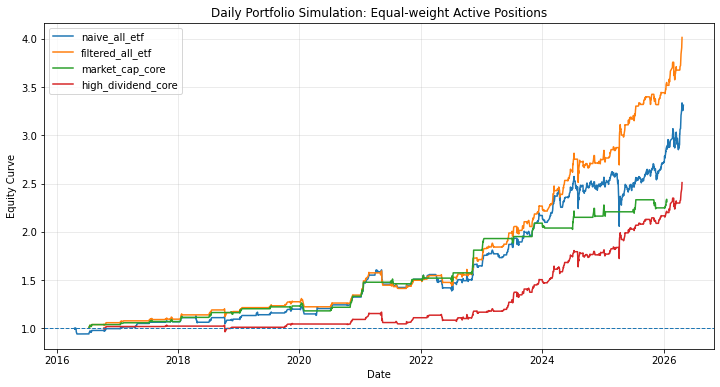

In [14]:
plt.figure(figsize=(12, 6))

for strategy_name, portfolio in daily_portfolio_tables.items():
    if portfolio.empty:
        continue

    x = pd.to_datetime(portfolio["date"]).to_numpy()
    y = portfolio["equity_curve"].to_numpy()

    plt.plot(x, y, label=strategy_name)

plt.axhline(1, linestyle="--", linewidth=1)
plt.title("Daily Portfolio Simulation: Equal-weight Active Positions")
plt.xlabel("Date")
plt.ylabel("Equity Curve")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 12. Daily portfolio drawdowns

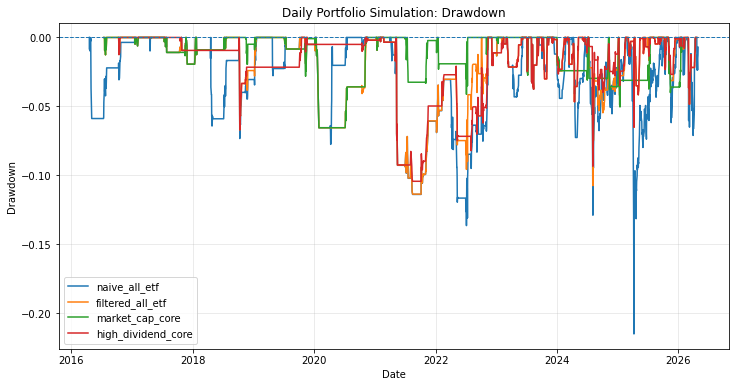

In [15]:
plt.figure(figsize=(12, 6))

for strategy_name, portfolio in daily_portfolio_tables.items():
    if portfolio.empty:
        continue

    x = pd.to_datetime(portfolio["date"]).to_numpy()
    y = portfolio["drawdown"].to_numpy()

    plt.plot(x, y, label=strategy_name)

plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Daily Portfolio Simulation: Drawdown")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 13. Inspect maximum overlapping positions

In [16]:
for strategy_name, portfolio in daily_portfolio_tables.items():
    if portfolio.empty:
        continue

    print("=" * 80)
    print(strategy_name)

    display(
        portfolio
        .sort_values("active_position_count", ascending=False)
        .head(20)[[
            "date",
            "active_position_count",
            "active_symbols",
            "equal_weight",
            "portfolio_return",
            "equity_curve",
            "drawdown",
        ]]
    )


naive_all_etf


,date,active_position_count,active_symbols,equal_weight,portfolio_return,equity_curve,drawdown
2247,2025-07-08,5,"0050,0056,006208,00929,00940",0.20,-0.005090,2.463060,-0.060171
2380,2026-01-19,5,"0050,0056,00929,00939,00940",0.20,0.006986,2.877492,0.000000
2407,2026-03-09,5,"00713,00919,00929,00939,00940",0.20,-0.030316,2.869093,-0.064988
2406,2026-03-06,5,"00713,00919,00929,00939,00940",0.20,0.001985,2.958791,-0.035756
2007,2024-07-09,5,"0050,0056,006208,00929,00940",0.20,0.000027,2.528381,0.000000
2006,2024-07-08,5,"0050,0056,006208,00929,00940",0.20,0.012378,2.528312,0.000000
2005,2024-07-05,5,"0050,0056,006208,00929,00940",0.20,-0.000306,2.497399,-0.000306
2246,2025-07-07,5,"0050,0056,006208,00929,00940",0.20,-0.004756,2.475660,-0.055364
2004,2024-07-04,5,"0050,0056,006208,00929,00940",0.20,0.015563,2.498163,0.000000
2003,2024-07-03,5,"0050,0056,006208,00929,00940",0.20,0.006087,2.459879,-0.001699


filtered_all_etf


,date,active_position_count,active_symbols,equal_weight,portfolio_return,equity_curve,drawdown
1951,2024-07-15,3,"0050,0056,006208",0.333333,-0.000140,2.752641,-0.021942
1703,2023-07-10,3,"0050,0056,006208",0.333333,-0.000546,1.954254,-0.025417
1058,2020-11-10,3,"006208,00713,00878",0.333333,-0.003139,1.303902,-0.003822
1059,2020-11-11,3,"006208,00713,00878",0.333333,0.009560,1.316368,0.000000
1060,2020-11-12,3,"006208,00713,00878",0.333333,-0.001181,1.314813,-0.001181
1061,2020-11-13,3,"006208,00713,00878",0.333333,0.002331,1.317877,0.000000
1062,2020-11-16,3,"006208,00713,00878",0.333333,0.015752,1.338636,0.000000
1946,2024-07-08,3,"0050,0056,006208",0.333333,0.021594,2.754330,0.000000
1947,2024-07-09,3,"0050,0056,006208",0.333333,-0.000300,2.753504,-0.000300
1948,2024-07-10,3,"0050,0056,006208",0.333333,0.004600,2.766171,0.000000


market_cap_core


,date,active_position_count,active_symbols,equal_weight,portfolio_return,equity_curve,drawdown
976,2020-07-14,2,"0050,006208",0.5,0.006773,1.212618,-0.040400
1944,2024-07-04,2,"0050,006208",0.5,0.025804,2.101650,0.000000
1946,2024-07-08,2,"0050,006208",0.5,0.030007,2.158375,0.000000
1947,2024-07-09,2,"0050,006208",0.5,0.000143,2.158685,0.000000
1948,2024-07-10,2,"0050,006208",0.5,0.003931,2.167170,0.000000
1949,2024-07-11,2,"0050,006208",0.5,0.022489,2.215908,0.000000
1950,2024-07-12,2,"0050,006208",0.5,-0.029660,2.150184,-0.029660
1951,2024-07-15,2,"0050,006208",0.5,0.000026,2.150240,-0.029635
972,2020-07-08,2,"0050,006208",0.5,0.007614,1.193871,-0.055236
973,2020-07-09,2,"0050,006208",0.5,0.002036,1.196302,-0.053312


high_dividend_core


,date,active_position_count,active_symbols,equal_weight,portfolio_return,equity_curve,drawdown
1621,2023-06-08,2,"00713,00919",0.5,-0.001597,1.220823,-0.001597
1799,2024-03-05,2,"00713,00919",0.5,0.008248,1.550654,0.000000
1864,2024-06-07,2,"00713,00919",0.5,0.003360,1.699984,0.000000
1929,2024-09-11,2,"00713,00919",0.5,0.000171,1.737391,-0.037980
1617,2023-06-02,2,"00713,00919",0.5,0.011654,1.210684,0.000000
1618,2023-06-05,2,"00713,00919",0.5,0.002796,1.214069,0.000000
1619,2023-06-06,2,"00713,00919",0.5,-0.000261,1.213753,-0.000261
1620,2023-06-07,2,"00713,00919",0.5,0.007434,1.222776,0.000000
1930,2024-09-12,2,"00713,00919",0.5,0.007671,1.750719,-0.030600
1622,2023-06-09,2,"00713,00919",0.5,0.011926,1.235383,0.000000


## 14. Export daily portfolio outputs

In [17]:
daily_portfolio_summary.to_csv(
    OUTPUT_DIR / "daily_portfolio_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

for strategy_name, portfolio in daily_portfolio_tables.items():
    portfolio.to_csv(
        OUTPUT_DIR / f"{strategy_name}_daily_portfolio.csv",
        index=False,
        encoding="utf-8-sig",
    )

for strategy_name, trades in strategy_trade_tables.items():
    trades.to_csv(
        OUTPUT_DIR / f"{strategy_name}_trades.csv",
        index=False,
        encoding="utf-8-sig",
    )

print("Saved daily portfolio outputs to:", OUTPUT_DIR)


Saved daily portfolio outputs to: C:\Users\USER\Desktop\ETF-alpha-lab\data\strategy


## 15. Interpretation checklist

這版 Notebook 的重點是看「一份資金」在重疊持倉時的真實分配結果。

解讀順序：

1. `total_return`：每日動態等權後的總報酬。
2. `annualized_return`：年化報酬。
3. `annualized_vol`：年化波動。
4. `sharpe_like`：年化報酬 / 年化波動，僅作簡化比較。
5. `max_drawdown`：最大回撤。
6. `avg_active_positions`：平均同時持有幾檔。
7. `max_active_positions`：最多同時持有幾檔。
8. `exposure_rate`：有持倉的天數比例。

若這版 daily portfolio simulation 後，Filtered All ETF 仍然明顯優於 Naive All ETF，代表篩選策略比無差別全 ETF 更有真實資金配置價值。

下一版可加入：
- announcement-date 可交易性檢查
- rebalance turnover cost
- slippage sensitivity
- 單檔權重上限
